## 1. Data Preparation (Preprocessing)

Before training a model, we need to prepare the data in the correct format.

**Step 1 — Separate features and target:**
- **Features (X):** The input columns the model uses to make a prediction (`age`, `sex`, `fare`, etc.).
- **Target (y):** The column we want to predict — `survived` (0 = not survived, 1 = survived).

**Step 2 — Feature scaling:**  
Because some numbers are very big and some are small, we need to scale them. For example, `fare` can be up to 512, but binary columns are only 0 or 1. Due to this difference, the model might think `fare` is more important just because the number is bigger. To fix this, we use `StandardScaler`. It changes the continuous features (`age`, `fare`, `family_size`) so they have a mean of 0 and a standard deviation of 1.

**Step 3 — Train/test split:**  
We split our data into a **training set** (80%) and a **test set** (20%). We do this because we need to check how good our model is on new data it hasn't seen before.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df_model = pd.read_csv('../data/titanic.csv')
df_model.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
# Define features and target
# FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
# FEATURES = ["sex"]
# TARGET = "survived"

# X = df_model[FEATURES]
# y = df_model[TARGET]

X = df_model.drop(columns=['survived']).copy()
# X = df_model.drop(columns=['survived', 'family_size']).copy()
y = df_model['survived']

# Split into training (80%) and test (20%) sets
# stratify=y ensures the same survival ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=81842, stratify=y
)

# Scale continuous features so they are on the same range
numerical_cols = ['age', 'fare', 'family_size']
# numerical_cols = ['fare', 'family_size']

scaler = StandardScaler()
# scaler = MinMaxScaler()
# scaler = RobustScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

#=================================
scaler_stats = pd.DataFrame({
    'Feature': numerical_cols,
    'Mean (μ)': scaler.mean_,
    'Std Dev (σ)': scaler.scale_
})

print("StandardScaler Parameters:")
print(scaler_stats)
#=================================
# scaler_stats = pd.DataFrame({
#     'Feature': numerical_cols,
#     'Min (found)': scaler.data_min_,
#     'Max (found)': scaler.data_max_
# })

# print("MinMaxScaler Parameters:")
# print(scaler_stats)
#=================================

print(f"\nTraining set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Features     : {X_train.columns.tolist()}")

StandardScaler Parameters:
       Feature   Mean (μ)  Std Dev (σ)
0          age  29.669732    13.970112
1         fare  31.592541    46.991252
2  family_size   0.892807     1.633506

Training set : 709 rows
Test set     : 178 rows
Features     : ['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class', '3rd_class']


**Preprocessing Results:**

* **Features (X):** We use 7 columns for our model: `sex`, `age`, `family_size`, `fare`, `1st_class`, `2nd_class`, `3rd_class`.
* **Scaling:** We only scaled `age`, `fare`, and `family_size` because the other columns are already 0 or 1.
* **Stratified split:** I used `stratify=y` during the split. This is important since we want the same percentage of survivors in both the training and test sets.

## 2. Model Training

Now we are ready to train our classification model. We will use **Logistic Regression** from the scikit-learn library.

Despite its name, logistic regression is a **classification** algorithm, not a regression one. It learns a weight (coefficient) for each input feature and combines them into a single score. This score is then passed through the **sigmoid function**, which converts it into a probability between 0 and 1. If the probability is above 0.5, the model predicts "survived"; otherwise, it predicts "not survived".

We set the parameter `max_iter=1000`. This just gives the model enough time (iterations) to find the best weights without stopping too early.

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=25842, C=5.0)
model.fit(X_train, y_train)

print("Model training complete!")
print(f"  Training samples used : {X_train.shape[0]}")
print(f"  Number of features    : {X_train.shape[1]}")

Model training complete!
  Training samples used : 709
  Number of features    : 7


The model has finished learning. It has adjusted its internal weights to best match the patterns in the training data. In the next step, we will measure how well it performs on the test set.

## 3. Model Evaluation

Training is only the first step. Now we must see how well the model works on the **test set** that we hid from it earlier.

We use several metrics because each one reveals something different about the model's quality:

| Metric | What it measures |
|--------|-----------------|
| **Accuracy** | The percentage of all predictions that are correct |
| **Precision** | Of all passengers predicted as "survived", how many actually survived? |
| **Recall** | Of all passengers who actually survived, how many did the model correctly find? |
| **F1 Score** | A balanced score that combines Precision and Recall into one number |
| **ROC-AUC** | How well the model separates the two classes (0.5 = random guessing, 1.0 = perfect) |

The **Confusion Matrix** gives a visual breakdown of all four possible prediction outcomes: correct predictions (True Positive, True Negative) and errors (False Positive, False Negative).

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")
print(f"ROC-AUC   : {roc_auc:.2f}")
print("\n=========== Detailed Classification Report ===========")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

Accuracy  : 0.85
Precision : 0.78
Recall    : 0.84
F1 Score  : 0.81
ROC-AUC   : 0.89

=========== Detailed Classification Report ===========
              precision    recall  f1-score   support

Not Survived       0.89      0.85      0.87       109
    Survived       0.78      0.84      0.81        69

    accuracy                           0.85       178
   macro avg       0.84      0.85      0.84       178
weighted avg       0.85      0.85      0.85       178



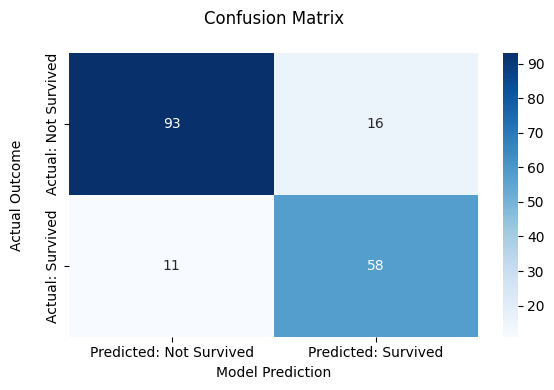

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Not Survived', 'Predicted: Survived'],
    yticklabels=['Actual: Not Survived', 'Actual: Survived'],
    ax=ax
)
ax.set_title('Confusion Matrix\n')
ax.set_xlabel('Model Prediction')
ax.set_ylabel('Actual Outcome\n')
plt.tight_layout()
plt.show()

**Key Findings:**

* **Accuracy:** The model correctly predicts the outcome for about 4 out of 5 passengers on the test set.
* **Precision vs. Recall trade-off:** In this task, high Recall matters — missing a real survivor (a False Negative) is a more costly mistake than a false alarm (a False Positive).
* **ROC-AUC:** A score well above 0.5 confirms that the model is significantly better than random guessing.
* **Baseline comparison:** A naive model that always predicts "not survived" would already reach ~61% accuracy (because 61.4% of passengers did not survive). Our logistic regression model clearly outperforms this baseline.

### 3.1. Cross-Validation 

To ensure our model's performance isn't just a lucky result of our specific 80/20 train-test split, we apply **Cross-Validation**. 
Cross-validation splits the training data into 5 folds, training the model on 4 folds and evaluating on the 5th, rotating until all folds have been the test set. This gives us a much more robust estimate of how the model will generalize.

In [7]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation on the full training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores  : {cv_scores}")
print(f"Mean CV Accuracy                  : {cv_scores.mean():.2f}")
print(f"Standard Deviation of CV Accuracy : {cv_scores.std():.2f}")

Cross-Validation Accuracy Scores  : [0.8028169  0.80985915 0.73943662 0.82394366 0.75177305]
Mean CV Accuracy                  : 0.79
Standard Deviation of CV Accuracy : 0.03


## 4. Understanding Feature Importance

After training, we can inspect the model's **coefficients** (weights) to understand which features have the most influence on its predictions.

In logistic regression, each feature is multiplied by its coefficient when calculating the prediction score. A **large positive coefficient** means the feature strongly increases the probability of survival. A **large negative coefficient** means it decreases it. Coefficients close to zero have little effect on the prediction.

Because we applied `StandardScaler` in Section 1, all continuous features are on the same scale. This means we can compare the coefficient magnitudes directly across all features.

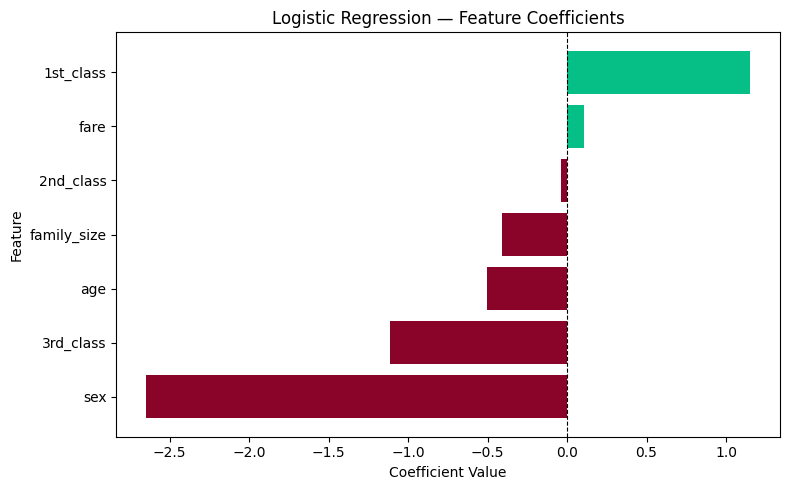

In [8]:
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#8a0329' if c < 0 else '#05bf87' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Feature Coefficients')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

**Key Findings:**

* **Sex** has the largest absolute coefficient, confirming it is the most influential feature. The direction of the effect matches the "women and children first" evacuation policy observed in the EDA.
* **1st_class** has a strong positive coefficient — first-class passengers had significantly higher survival chances.
* **3rd_class** has a negative coefficient — third-class passengers were much less likely to survive.
* **Age** has a small negative coefficient — older passengers were slightly less likely to survive, but the effect is weaker than class or sex.
* These results are consistent with the patterns we discovered during the EDA phase, which adds confidence to the model's behavior.